In [27]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data 
y = mnist.target.astype(int)

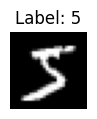

In [28]:
i=0
plt.figure(figsize=(2,1))
plt.imshow(X[i].reshape(28,28),cmap='gray')
plt.title(f"Label: {y[i]}")
plt.axis("off")
plt.show()

In [29]:
def plot_digits(X,y,num_images=10):
    plt.figure(figsize=(10,4))
    for i in range(num_images):
        plt.subplot(2,5,i+1)
        plt.imshow(X[i].reshape(28,28),cmap='gray')
        plt.title(f"Label: {y[i]}")
        plt.axis("off")
plt.show()

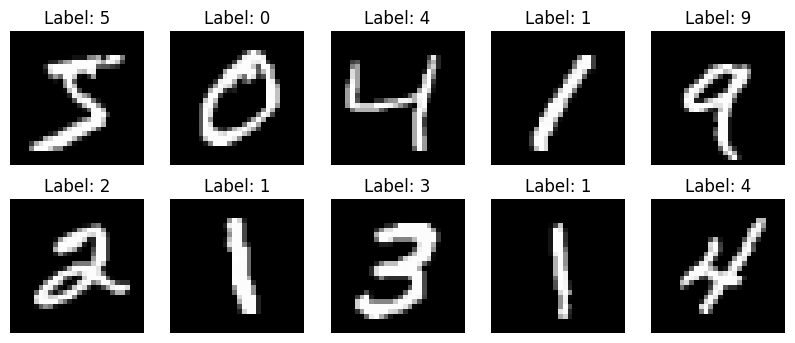

In [30]:
plot_digits(X,y)

In [31]:
#Split the data into training and testing test

X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
#use StandarScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [33]:
#Save the scaler to future use

import joblib
joblib.dump(scaler,'scaler.pkl')
print("Success")

Success


In [34]:
#Random Froest Model 

rf_model= RandomForestClassifier(n_estimators=100,n_jobs=1,random_state=42)
rf_model.fit(X_train_scaled,y_train)

#Save the model
joblib.dump(rf_model,'mnist_random_forest.pkl')
print("Success")

Success


In [35]:
#Make predictions on the test data

y_preds=rf_model.predict(X_test_scaled)

accuracy=accuracy_score(y_true=y_test,y_pred=y_preds)*100
print(f"Accuracy={accuracy:4f}")

Accuracy=96.742857


In [40]:
def visualize_predictions(X_test,y_test,y_preds,num_images=10):
    plt.figure(figsize=(10,5))
    for i in range(num_images):
        plt.subplot(2,5,i+1)
        plt.imshow(X_test[i].reshape(28,28),cmap='gray')
        plt.title(f"True:{y_test[i]}\nPredicted:{y_preds[i]}")
        plt.axis("off")
    plt.show()

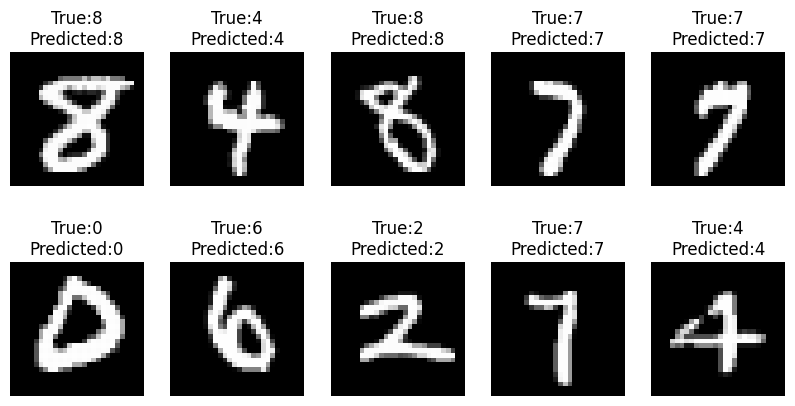

In [41]:
visualize_predictions(X_test,y_test,y_preds)